In [1]:
# For processing the timeseries
import pandas as pd, os, datetime
import numpy as np

# For plotting
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import plotly.express as px
pio.renderers.default = 'notebook'

In [2]:
os.chdir('/g/data/ng72/ms5578/ID_HW_BARRA')

nmap_path = '/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess'
ehf_fpath = '/scratch/ng72/ms5578/time_series'
gen_fpath = '/scratch/ng72/ms5578/time_series/nem_generation'

In [4]:
gen_details = pd.read_csv(f"{nmap_path}/gen_details.csv")

In [5]:
hw_tseries = pd.read_csv(f"{ehf_fpath}/gen_hw_status.csv")

In [6]:
def process_group(grp, gen_fpath, hw_tseries, start_date=sdate, end_date=edate):
    """
    Processes a single group of generator data.

    Parameters:
        grp (pd.DataFrame): A single group from gen_details (e.g., from groupby('region')).
        gen_fpath (str): Path to directory containing CSV files named by DUID (e.g., DUID.csv).
        hw_tseries (pd.DataFrame): DataFrame with columns 'time', 'DUID', and data to merge.
        start_date (str): Start date for subsetting the time series.
        end_date (str): End date for subsetting the time series.

    Returns:
        pd.DataFrame: The merged result for the group.
    """
    gen_locs = gen_fpath + '/' + grp['DUID'] + ".csv"
    dfs = [pd.read_csv(fp,dtype='object') for fp in gen_locs if os.path.exists(fp)]

    if not dfs:
        return None

    # This is in case of accidental mid-file headers
    dfs = pd.concat(dfs, ignore_index=True)
    header_row = dfs.columns.tolist()
    dfs = dfs[~dfs.apply(lambda row: list(row) == header_row, axis=1)]

    # This is to correct the column types after removing header rows
    dfs['time'] = pd.to_datetime(dfs['time'])
    dfs['TOTALCLEARED'] = dfs['TOTALCLEARED'].astype(float)
    dfs['TOTALMWh'] = dfs['TOTALMWh'].astype(float)
    dfs['AGCSTATUS'] = pd.to_numeric(dfs['AGCSTATUS'], errors='coerce').fillna(0).astype(int)
    
    dfs['time'] = pd.to_datetime(dfs['time'])
    dfs = dfs.set_index('time').sort_index()
    dfs = dfs.loc[start_date:end_date]

    # Group by DUID and hourly time, sum TOTALMWh
    agg_func = {'TOTALMWh':'sum','TOTALCLEARED':'sum','AGCSTATUS':'min'}
    grouped = dfs.groupby(['DUID', pd.Grouper(freq='1d')]).agg(agg_func).reset_index()

    hw_tseries['time'] = pd.to_datetime(hw_tseries['time'])
    hw_tseries = hw_tseries.set_index(['time']).sort_index()
    hw_tseries = hw_tseries.loc[sdate:edate]
    hw_tseries = hw_tseries.reset_index().set_index(['DUID','time']).sort_index()

    merged = pd.merge_asof(
        grouped.sort_values(by=['time', 'DUID']),
        hw_tseries.sort_values(by=['time', 'DUID']),
        by='DUID',
        on='time',
        tolerance=pd.Timedelta("1d"),
        direction='nearest'
    )

    return merged

In [7]:
def process_all(gen_details, gen_fpath, hw_tseries, start_date=sdate, end_date=edate):
    """
    Process all generator data in gen_details without grouping. Ignores loads and batteries.
    
    Parameters:
        gen_details (pd.DataFrame): DataFrame containing at least 'duid' column.
        gen_fpath (str): Directory path containing CSV files named by DUID.
        hw_tseries (pd.DataFrame): Heatwave timeseries data with 'time' and 'DUID'.
        start_date (str): Start date for filtering time series.
        end_date (str): End date for filtering time series.
    
    Returns:
        pd.DataFrame: Merged dataframe with summed TOTALMWh per DUID per hour and heatwave info.
    """
    # Build file paths for all DUIDs,ignoring batteries
    non_batt = gen_details[gen_details['fuel_source_primary'] != 'Battery']
    non_batt = non_batt[non_batt['fuel_source_primary'] != '-']
    non_batt = non_batt[non_batt['dispatch_type'] == 'Generator']['DUID']
    gen_locs = gen_fpath + '/' + non_batt + ".csv"

    # Read all existing CSVs
    dfs = [pd.read_csv(fp) for fp in gen_locs if os.path.exists(fp)]
    
    if not dfs:
        print("[WARN] No data files found for any DUID.")
        return pd.DataFrame()  # Return empty if no files
    
    # Concatenate all data
    dfs = pd.concat(dfs, ignore_index=True)

    # This is in case of accidental mid-file headers
    header_row = dfs.columns.tolist()
    dfs = dfs[~dfs.apply(lambda row: list(row) == header_row, axis=1)]

    # This is to correct the column types after removing header rows
    dfs['time'] = pd.to_datetime(dfs['time'])
    dfs['TOTALCLEARED'] = dfs['TOTALCLEARED'].astype(float)
    dfs['TOTALMWh'] = dfs['TOTALMWh'].astype(float)
    dfs['AGCSTATUS'] = pd.to_numeric(dfs['AGCSTATUS'], errors='coerce').fillna(0).astype(int)

    # Convert time to datetime and filter
    dfs['time'] = pd.to_datetime(dfs['time'])
    dfs = dfs.set_index('time').sort_index()
    dfs = dfs.loc[start_date:end_date]

    # Group by DUID and hourly time, sum TOTALMWh
    agg_func = {'TOTALMWh':'sum','TOTALCLEARED':'sum','AGCSTATUS':'min'}
    grouped = dfs.groupby(['DUID', pd.Grouper(freq='1h')]).agg(agg_func).reset_index()

    # Sort hw_tseries and convert column types
    hw_sorted = hw_tseries.sort_values(by=['time', 'DUID'])
    hw_tseries['time'] = pd.to_datetime(hw_tseries['time'])
    hw_tseries = hw_tseries.set_index(['time']).sort_index()
    hw_tseries = hw_tseries.loc[sdate:edate]
    hw_tseries = hw_tseries.reset_index().set_index(['DUID','time']).sort_index()

    # Merge with heatwave timeseries
    merged = pd.merge_asof(
        grouped.sort_values(by=['time', 'DUID']),
        hw_sorted,
        by='DUID',
        on='time',
        tolerance=pd.Timedelta("1d"),
        direction='nearest'
    )
    
    return merged

In [15]:
def select_group(gen_details=gen_details, state=None,ftype=None):
    if state is not None and ftype is not None:
        groups = gen_details.groupby(['region','fuel_source_primary'])
        grp = groups.get_group((state,ftype))
    elif state is not None:
        groups = gen_details.groupby('region')
        grp = groups.get_group(state)
    elif ftype is not None:
        groups = gen_details.groupby('fuel_source_primary')
        grp = groups.get_group(ftype)

    return grp

sdate, edate = '2009-07-01','2024-06-30'
group = select_group(ftype='Wind')
df = process_group(group, gen_fpath, hw_tseries,sdate,edate)

In [16]:
df = df.merge(gen_details[['DUID', 'reg_cap_mw']], on='DUID', how='left')
df['reg_cap_mw'] = df['reg_cap_mw'].astype('float')
df['cap_norm'] = df['TOTALMWh']/df['reg_cap_mw']
df = df[~((df['cap_norm'] > 1) | (df['cap_norm'] <0)) ]

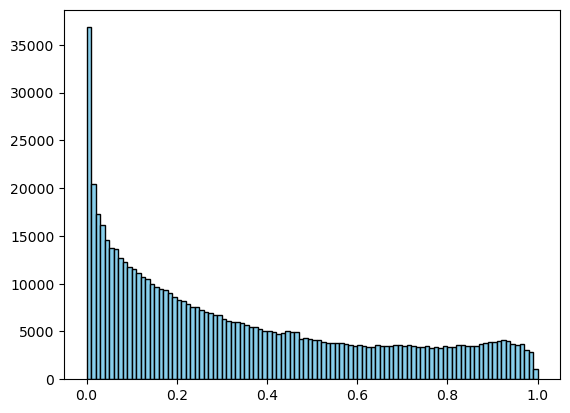

In [17]:
plt.hist(df[~(df['cap_norm'] == 0)]['cap_norm'], bins=100, color='skyblue', edgecolor='black');